In [ ]:
# Task 1: Data Immersion & Wrangling
## ApexPlanet Data Analytics Internship

In [ ]:
## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## 2. Load Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ApexPlanet_DataAnalytics_Dataset.xlsx to ApexPlanet_DataAnalytics_Dataset.xlsx


In [ ]:
import os
print(os.listdir())

['.config', 'ApexPlanet_DataAnalytics_Dataset.xlsx', 'sample_data']


In [ ]:
## 3. Dataset Overview
This section provides a quick overview of the dataset structure.

In [ ]:
import pandas as pd

df = pd.read_excel("ApexPlanet_DataAnalytics_Dataset.xlsx")
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [ ]:
df.shape

(1000, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   object 
 6   City           987 non-null    object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 93.9+ KB


In [ ]:
## 4. Data Profiling
Statistical summary of numerical columns.

In [ ]:
df.describe()

,Order_Date,Age,Quantity,Unit_Price,Total_Sales
count,1000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2025-07-03 11:19:40.800000,41.353000,5.435000,25486.783410,139399.439650
min,2025-01-01 00:00:00,18.000000,1.000000,145.780000,437.340000
25%,2025-03-30 18:00:00,30.000000,3.000000,13895.722500,47066.632500
50%,2025-07-01 00:00:00,41.000000,5.000000,25398.740000,108594.025000
75%,2025-10-07 06:00:00,53.000000,8.000000,37512.382500,203722.882500
max,2026-01-01 00:00:00,65.000000,10.000000,49997.530000,493677.500000
std,NaN,13.683626,2.838632,14179.402361,114100.051546


In [ ]:
## 5. Missing Value Analysis
Checking for missing values in the dataset.

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,20
Gender,0
City,13
Product,0
Category,0
Quantity,0


In [ ]:
## 6. Data Cleaning
Handling missing values using appropriate techniques.

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [ ]:
df['City'] = df['City'].fillna(df['City'].mode()[0])

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,0
Gender,0
City,0
Product,0
Category,0
Quantity,0


In [ ]:
## 7. Duplicate Check
Checking for duplicate records.

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
## 8. Date Conversion
Converting Order_Date to datetime format.

In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       1000 non-null   object        
 1   Order_Date     1000 non-null   datetime64[ns]
 2   Customer_ID    1000 non-null   object        
 3   Customer_Name  1000 non-null   object        
 4   Age            1000 non-null   float64       
 5   Gender         1000 non-null   object        
 6   City           1000 non-null   object        
 7   Product        1000 non-null   object        
 8   Category       1000 non-null   object        
 9   Quantity       1000 non-null   int64         
 10  Unit_Price     1000 non-null   float64       
 11  Total_Sales    1000 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(7)
memory usage: 93.9+ KB


In [ ]:
## 9. Sales Validation
Validating Total_Sales using Quantity × Unit_Price.

In [ ]:

(df['Quantity'] * df['Unit_Price'] == df['Total_Sales']).all()

np.False_

In [ ]:
df['Calculated_Sales'] = df['Quantity'] * df['Unit_Price']

mismatch = df[df['Calculated_Sales'] != df['Total_Sales']]
print(len(mismatch))

mismatch[['Quantity','Unit_Price','Total_Sales','Calculated_Sales']].head()

178


,Quantity,Unit_Price,Total_Sales,Calculated_Sales
7,3,9488.83,28466.49,28466.49
21,7,15396.37,107774.59,107774.59
24,7,36069.86,252489.02,252489.02
27,5,14534.79,72673.95,72673.95
32,5,17556.08,87780.40,87780.40


In [ ]:
(
    round(df['Quantity'] * df['Unit_Price'], 2)
    == round(df['Total_Sales'], 2)
).all()

np.True_

In [ ]:
df.drop('Calculated_Sales', axis=1, inplace=True)

In [ ]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age',
       'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Total_Sales'],
      dtype='object')

In [ ]:
print(df.shape)
print(df.isnull().sum().sum())
print(df.duplicated().sum())

(1000, 12)
0
0


In [ ]:
## 10. Outlier Detection
Visual inspection of outliers using boxplots.

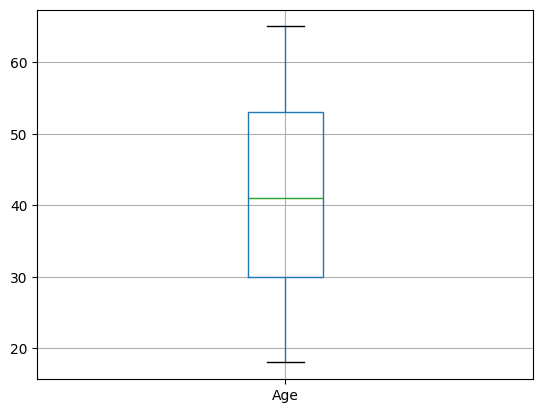

In [ ]:
df.boxplot(column='Age')
plt.show()

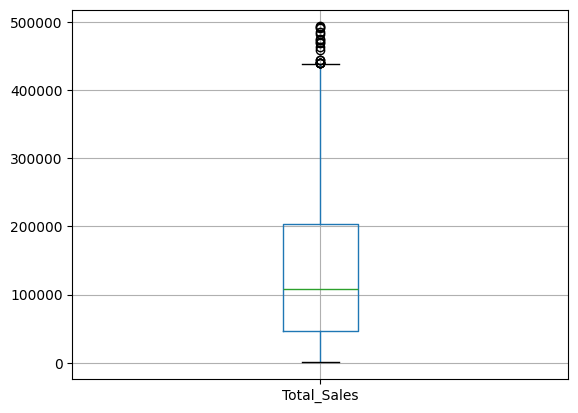

In [ ]:
df.boxplot(column='Total_Sales')
plt.show()

In [ ]:
## 11. Save Cleaned Dataset
Exporting the cleaned dataset.

In [ ]:
df.to_excel("Cleaned_ApexPlanet_Dataset.xlsx", index=False)

In [ ]:
## 12. Conclusion

The dataset was successfully cleaned and prepared for analysis.

- Total Records: 1000
- Total Columns: 12
- Missing values handled successfully
- No duplicate records found
- Order_Date converted to datetime format
- Total_Sales validated
- Outliers inspected using boxplots

The dataset is now ready for exploratory data analysis and visualization.

In [ ]:
from google.colab import files
files.download("Cleaned_ApexPlanet_Dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>